# Day 38 — Choosing Dimensions & PCA Variants

- Explained variance ratio
- Choosing the number of dimensions
- Cumulative explained variance
- Reconstruction error
- PCA with a target variance threshold
- PCA variants: randomized PCA and Incremental PCA


## 1. Imports

We will use NumPy, Matplotlib, and scikit-learn.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

np.random.seed(42)



## 2. Load a Real Dataset

We will use the **Digits dataset**. Each handwritten digit image is represented by 64 pixel features.

This gives us a useful high-dimensional dataset for experimenting with PCA.


In [2]:

digits = load_digits()
X = digits.data
y = digits.target

print("Dataset shape:", X.shape)
print("Number of features:", X.shape[1])
print("Number of classes:", len(np.unique(y)))


Dataset shape: (1797, 64)
Number of features: 64
Number of classes: 10



## 3. Visualize a Few Original Digits

PCA works on the numerical feature representation, while the original data can still be visualized as 8×8 images.


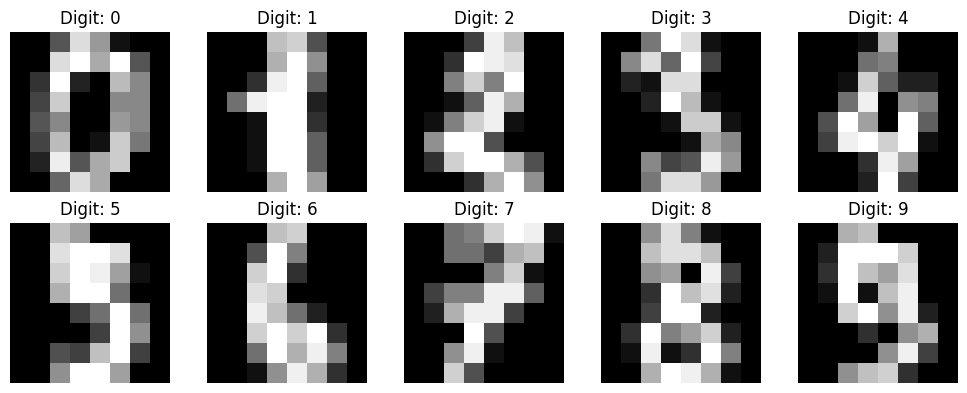

In [3]:

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, image, label in zip(axes.ravel(), digits.images[:10], y[:10]):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Digit: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()



## 4. Fit PCA and Inspect Explained Variance Ratio

`explained_variance_ratio_` tells us what fraction of the dataset's total variance is captured by each principal component.

For example, if PC1 has a ratio of `0.15`, it captures about **15% of the total variance**.


In [4]:

pca = PCA()
X_pca = pca.fit_transform(X)

explained_variance = pca.explained_variance_ratio_

print("First 10 explained variance ratios:")
print(np.round(explained_variance[:10], 4))

print("\nTotal explained variance:")
print(explained_variance.sum())


First 10 explained variance ratios:
[0.1489 0.1362 0.1179 0.0841 0.0578 0.0492 0.0432 0.0366 0.0335 0.0308]

Total explained variance:
1.0



## 5. Cumulative Explained Variance

Individual components are useful, but when choosing how many dimensions to keep, **cumulative explained variance** is usually more useful.

It answers:

> How much of the original variance is preserved if I keep the first *n* components?


In [5]:

cumulative_variance = np.cumsum(explained_variance)

for n in [1, 2, 5, 10, 20, 30, 40, 50, 64]:
    print(f"{n:2d} components -> {cumulative_variance[n-1]:.2%} variance preserved")


 1 components -> 14.89% variance preserved
 2 components -> 28.51% variance preserved
 5 components -> 54.50% variance preserved
10 components -> 73.82% variance preserved
20 components -> 89.43% variance preserved
30 components -> 95.91% variance preserved
40 components -> 98.82% variance preserved
50 components -> 99.95% variance preserved
64 components -> 100.00% variance preserved


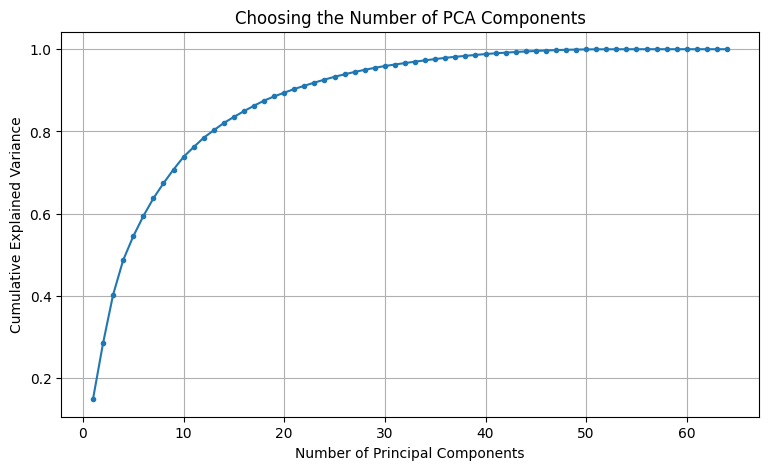

In [6]:

plt.figure(figsize=(9, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o",
    markersize=3
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Choosing the Number of PCA Components")
plt.grid(True)
plt.show()



## 6. Choose the Number of Dimensions for 90%, 95%, and 99%

A common strategy is to select the smallest number of components that reaches a target variance threshold.

For example:

- 90% → stronger compression
- 95% → common practical target
- 99% → preserve more information


In [7]:

for threshold in [0.90, 0.95, 0.99]:
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    print(
        f"{threshold:.0%} variance -> "
        f"{n_components} components"
    )


90% variance -> 21 components
95% variance -> 29 components
99% variance -> 41 components



## 7. Let PCA Choose the Number of Components

Instead of manually calculating the number of components, scikit-learn allows us to specify a variance threshold.

```python
PCA(n_components=0.95)
```

This means:

> Keep the smallest number of principal components that preserve at least 95% of the variance.


In [8]:

pca_95 = PCA(n_components=0.95)
X_reduced = pca_95.fit_transform(X)

print("Original shape:", X.shape)
print("Reduced shape:", X_reduced.shape)
print("Variance preserved:", pca_95.explained_variance_ratio_.sum())


Original shape: (1797, 64)
Reduced shape: (1797, 29)
Variance preserved: 0.9547965245651595



## 8. Reconstruction Error

Dimensionality reduction generally loses some information.

We can transform the data into the reduced space and then use:

```python
pca.inverse_transform(...)
```

to reconstruct an approximation of the original data.

The difference between the original and reconstructed data represents information lost by PCA.


In [9]:

# Fit PCA with 2 components
pca_2 = PCA(n_components=2)

X_2d = pca_2.fit_transform(X)
X_reconstructed = pca_2.inverse_transform(X_2d)

reconstruction_mse = np.mean((X - X_reconstructed) ** 2)

print("Reduced shape:", X_2d.shape)
print("Explained variance:", pca_2.explained_variance_ratio_.sum())
print("Reconstruction MSE:", reconstruction_mse)


Reduced shape: (1797, 2)
Explained variance: 0.2850936482369929
Reconstruction MSE: 13.421012200761451



## 9. Compare Reconstruction Error at Different Dimensions

Let's see what happens as we increase the number of principal components.

Expected relationship:

**More components → more information retained → lower reconstruction error**


In [10]:

component_counts = [2, 5, 10, 20, 30, 40, 50, 64]
reconstruction_errors = []
variance_preserved = []

for n in component_counts:
    pca_n = PCA(n_components=n)
    X_n = pca_n.fit_transform(X)
    X_recovered = pca_n.inverse_transform(X_n)

    mse = np.mean((X - X_recovered) ** 2)

    reconstruction_errors.append(mse)
    variance_preserved.append(pca_n.explained_variance_ratio_.sum())

for n, var, error in zip(component_counts, variance_preserved, reconstruction_errors):
    print(f"{n:2d} components | variance: {var:.2%} | reconstruction MSE: {error:.4f}")


 2 components | variance: 28.51% | reconstruction MSE: 13.4210
 5 components | variance: 54.50% | reconstruction MSE: 8.5424
10 components | variance: 73.82% | reconstruction MSE: 4.9143
20 components | variance: 89.43% | reconstruction MSE: 1.9843
30 components | variance: 95.91% | reconstruction MSE: 0.7681
40 components | variance: 98.82% | reconstruction MSE: 0.2215
50 components | variance: 99.95% | reconstruction MSE: 0.0085
64 components | variance: 100.00% | reconstruction MSE: 0.0000


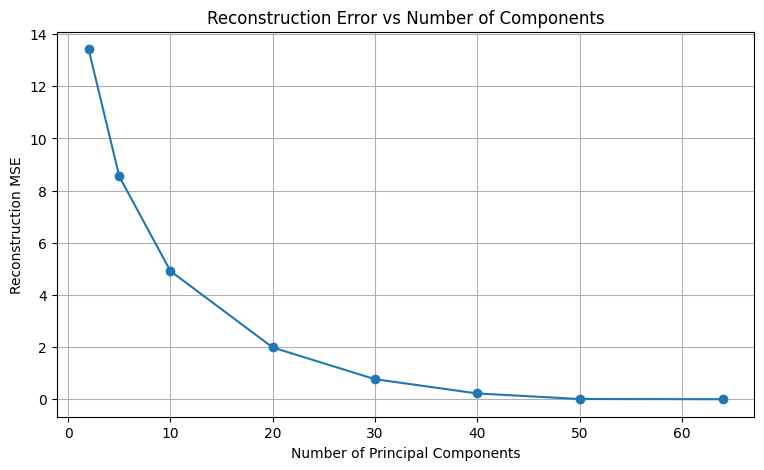

In [11]:

plt.figure(figsize=(9, 5))
plt.plot(component_counts, reconstruction_errors, marker="o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Reconstruction MSE")
plt.title("Reconstruction Error vs Number of Components")
plt.grid(True)
plt.show()



## 10. Visualize Original vs Reconstructed Data

Using only a small number of components produces a rough approximation.

As the number of components increases, the reconstruction becomes closer to the original.


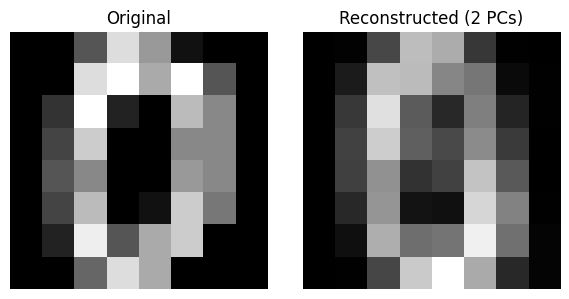

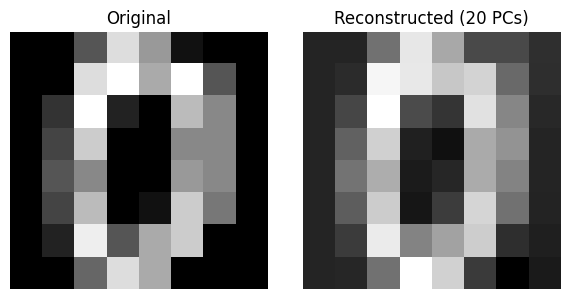

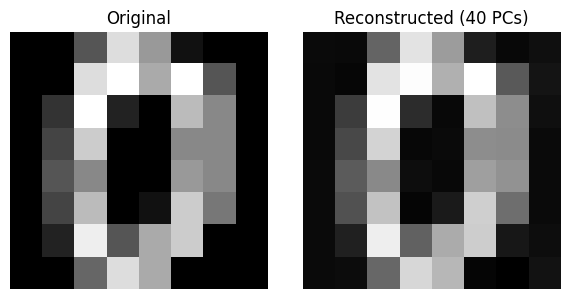

In [12]:

def show_reconstruction(n_components, sample_index=0):
    pca = PCA(n_components=n_components)
    X_reduced = pca.fit_transform(X)
    X_recovered = pca.inverse_transform(X_reduced)

    fig, axes = plt.subplots(1, 2, figsize=(6, 3))

    axes[0].imshow(X[sample_index].reshape(8, 8), cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(X_recovered[sample_index].reshape(8, 8), cmap="gray")
    axes[1].set_title(f"Reconstructed ({n_components} PCs)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

show_reconstruction(2)
show_reconstruction(20)
show_reconstruction(40)



## 11. PCA Variants — Randomized PCA

For large datasets, scikit-learn's PCA can use a **randomized SVD** solver.

```python
PCA(n_components=...)
```

By default, the solver selection depends on the problem. We can explicitly request:

```python
PCA(n_components=10, svd_solver="randomized")
```

Randomized PCA can be considerably faster when we only need a relatively small number of components from a very large dataset.


In [13]:

randomized_pca = PCA(
    n_components=10,
    svd_solver="randomized",
    random_state=42
)

X_randomized = randomized_pca.fit_transform(X)

print("Randomized PCA shape:", X_randomized.shape)
print("Variance preserved:", randomized_pca.explained_variance_ratio_.sum())


Randomized PCA shape: (1797, 10)
Variance preserved: 0.7382259784334533



## 12. Incremental PCA

**Incremental PCA (IPCA)** processes data in batches instead of requiring the entire dataset to be processed at once.

This is useful when:
- the dataset is too large to fit comfortably in memory,
- data arrives in batches,
- or we want a more memory-friendly PCA workflow.


In [14]:

n_components = 20

ipca = IncrementalPCA(
    n_components=n_components,
    batch_size=128
)

for batch in np.array_split(X, 10):
    ipca.partial_fit(batch)

X_ipca = ipca.transform(X)

print("Incremental PCA shape:", X_ipca.shape)
print("Approx. variance captured:", ipca.explained_variance_ratio_.sum())


Incremental PCA shape: (1797, 20)
Approx. variance captured: 0.8899383955569677



## 13. PCA + Standardization

PCA is sensitive to feature scales.

If features have very different scales, it is often appropriate to standardize them before PCA:

```text
Original data
     ↓
StandardScaler
     ↓
PCA
     ↓
Reduced representation
```

For the digits dataset, all pixel features are already on the same general scale, so standardization is not strictly necessary. This section demonstrates the standard workflow.


In [15]:

scaled_pca = make_pipeline(
    StandardScaler(),
    PCA(n_components=0.95)
)

X_scaled_reduced = scaled_pca.fit_transform(X)

print("Original shape:", X.shape)
print("Scaled + PCA shape:", X_scaled_reduced.shape)


Original shape: (1797, 64)
Scaled + PCA shape: (1797, 40)


In [16]:

# Your experiment
for threshold in [0.90, 0.95, 0.99]:
    pca = PCA(n_components=threshold)
    X_reduced = pca.fit_transform(X)

    print(
        f"Target={threshold:.0%} | "
        f"components={pca.n_components_:2d} | "
        f"actual variance={pca.explained_variance_ratio_.sum():.2%}"
    )


Target=90% | components=21 | actual variance=90.32%
Target=95% | components=29 | actual variance=95.48%
Target=99% | components=41 | actual variance=99.01%



# Day 38 — Summary

### Core ideas

**1. Explained variance ratio**
- Measures how much variance each principal component captures.
- `pca.explained_variance_ratio_`

**2. Cumulative explained variance**
- Shows how much total variance is preserved by the first *n* components.
- `np.cumsum(pca.explained_variance_ratio_)`

**3. Choosing dimensions**
- Choose the smallest number of components that meets your desired variance threshold.
- Example: `PCA(n_components=0.95)`

**4. Reconstruction error**
- Measures how much information is lost during dimensionality reduction.
- More components generally produce lower reconstruction error.

**5. Randomized PCA**
- Can speed up PCA when only a limited number of components are required from a large dataset.

**6. Incremental PCA**
- Processes data in batches.
- Useful for datasets that do not fit comfortably into memory.

### Mental model

```text
             PCA
High-D ───────────────→ Low-D
  │                       │
  │                       │
  └──── information ──────┘
          is lost

Choose enough components to keep
the information your application needs.
```

### Key takeaway

> **Don't choose the number of dimensions arbitrarily. Use explained variance and reconstruction error to make a data-driven trade-off between compression and information preservation.**
